# Movie Rating Prediction with Python
Complete ML pipeline including EDA, preprocessing, modeling and evaluation.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("IMBD_movies.csv", encoding="latin1")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [30]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [31]:
df = df.dropna(subset=['Rating'])
df = df.drop_duplicates()

In [32]:
df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Fill missing year with median
df['Year'] = df['Year'].fillna(df['Year'].median())

df['Movie_Age'] = 2026 - df['Year']

In [33]:
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Fill missing votes with median
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

df['Log_Votes'] = np.log1p(df['Votes'])

In [34]:
df = df[(df['Rating'] >= 1) & (df['Rating'] <= 10)]

print(df.shape)
df.head()

(7919, 12)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Movie_Age,Log_Votes
1,#Gadhvi (He thought he was Gandhi),2019,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,7,2.197225
3,#Yaaram,2019,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,7,3.583519
5,...Aur Pyaar Ho Gaya,1997,147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,29,6.719013
6,...Yahaan,2005,142 min,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,21,6.991177
8,?: A Question Mark,2012,82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,14,5.789960


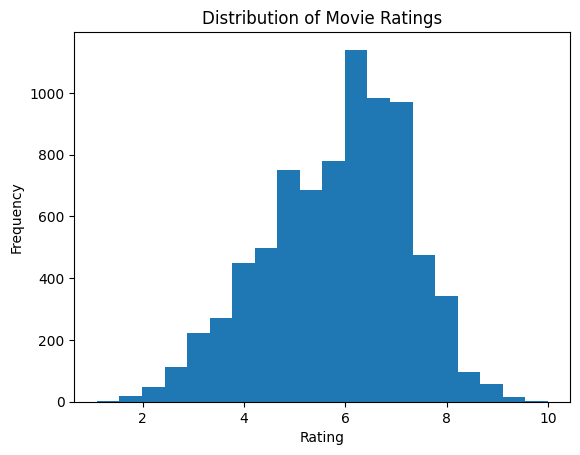

In [35]:
plt.figure()
plt.hist(df['Rating'], bins=20)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

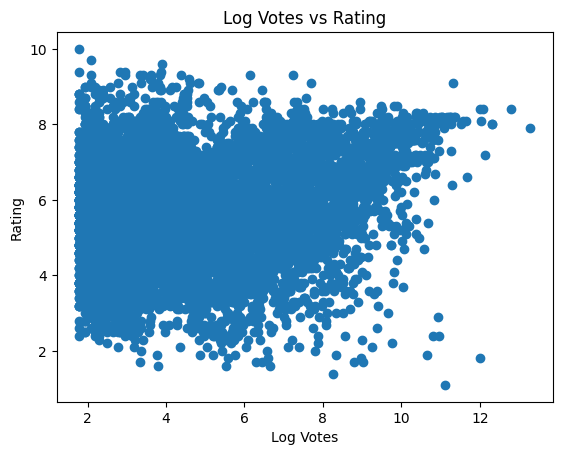

In [36]:
plt.figure()
plt.scatter(df['Log_Votes'], df['Rating'])
plt.title("Log Votes vs Rating")
plt.xlabel("Log Votes")
plt.ylabel("Rating")
plt.show()

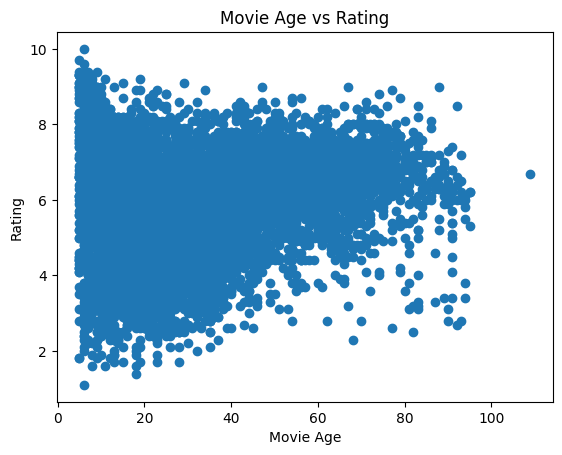

In [37]:
plt.figure()
plt.scatter(df['Movie_Age'], df['Rating'])
plt.title("Movie Age vs Rating")
plt.xlabel("Movie Age")
plt.ylabel("Rating")
plt.show()

In [38]:
df_model = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3',
                  'Movie_Age', 'Log_Votes', 'Rating']].dropna()

In [39]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [41]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Rating', axis=1)
y = df_model['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 1.2527577662404463
R2 Score: 0.3238706355830455


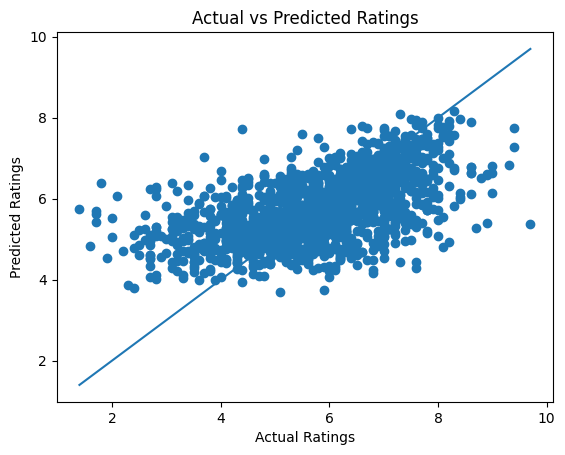

In [43]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

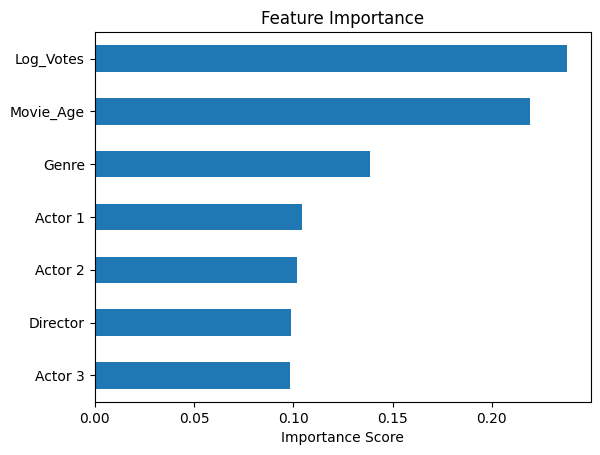

In [44]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)

plt.figure()
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()